In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output
import sys
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from scipy.optimize import curve_fit

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack, selection, fitting)
from utils_lya_halo import uv_profile as uv
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

from tests import psf_exponential_recovery as pfit
from astroquery.gaia import Gaia

# Reading in output and stacking

In [2]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.0            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 80             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 80
bg_outer_arcsec = 90

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 1000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg2 = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    n_bootstrap=n_bootstrap,
    #flux_unit='flux_arcsec2',
    #rest_density=False,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg2.cut_radial_bin, cfg2.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
prod_combined = multicat.combine_products(products, label_col="SUBSET")

print(f"AEGIS: {np.round(np.median(product1.nfib, axis=0), 3).astype(int)}")
print(f"COSMOS: {np.round(np.median(product2.nfib, axis=0), 3).astype(int)}")
print(f"COMBINED: {np.round(np.median(prod_combined.nfib, axis=0), 3).astype(int)}")

Finite-spectrum cut (bin 9, > 100 px): kept 233 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 277 / 278 galaxies
combined 2 products -> 510 galaxies (origin in column 'SUBSET')
AEGIS: [    24     70    115    373    911   3128  16911  62091 126573 586721]
COSMOS: [    15     43     70    220    536   1809   9820  37073  87936 402380]
COMBINED: [    17     51     81    258    615   2038  10906  41317  97244 448919]


In [37]:
# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg2, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks_all = stack.build_stacks(cfg2, prod_combined, keep_cube=True)

print(f"BOTH:   {prod_combined.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

# ---------------------------------------------------------------- SEPARATE AGN
sel_agn = prod_combined.catalog["CLEAN"] #prod_combined

groups = selection.split_by_mask(prod_combined, sel_agn, labels=["AGN", "GAL"], verbose=False) #prod_combined
prod_galaxy = groups['GAL']
prod_agn = groups['AGN']

stacks = build_stacks(cfg2, prod_galaxy, keep_cube=True)
stacks_agn = build_stacks(cfg2, prod_agn, keep_cube=True)

print(f"GAL: {prod_galaxy.ngal} sources")
print(f"AGN: {prod_agn.ngal} sources")

BOTH:   510 galaxies
AEGIS:  233 galaxies
COSMOS: 277 galaxies
GAL: 443 sources
AGN: 67 sources


# Bootstrap Pipeline

In [38]:
boot_b = measure.measure_all_bins(cfg2, stacks,
    seed=random_seed,
    verbose=True)

boot = boot_b

▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=10


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]

In [40]:
xlims = (3, 3000)

# Real Data Fitting

fit_psf_aware: WITH PSF forward model, all 10 bins fit (inner bin kept)
[psf] converged  chi2/dof = 7.04/6 = 1.17
    A1 =    6.193e+39 +/- 4.88e+38  
    h1 =        16.98 +/- 1.04      
    A2 =    7.256e+37 +/- 1.3e+37   
    h2 =         1594 +/- 568       


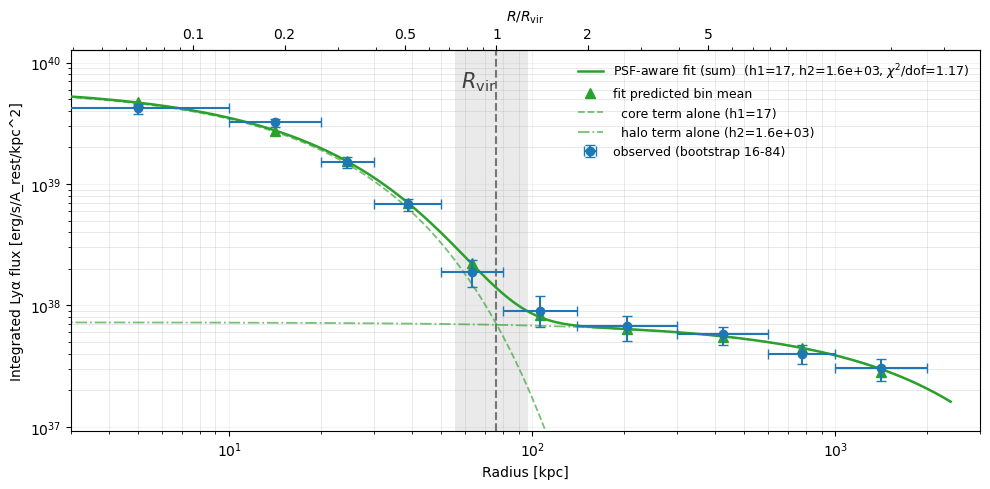

[psf fit vs real data] converged  chi2/dof = 7.04/6 = 1.17
    A1 =    6.193e+39 +/- 4.88e+38  
    h1 =        16.98 +/- 1.04      
    A2 =    7.256e+37 +/- 1.3e+37   
    h2 =         1594 +/- 568       


In [41]:
fig, ax, fit_twoexp = analysis.plot_flux_profile_fit(boot, stacks,
    method="psf",       # "psf" | "naive"
    fit_skip_inner=1,
    psf_r=None,
    psf_vals=None,
    psf_fwhm=3.0,
    psf_beta=3.0,
    p0=None,
    r_fine=None,
    logy=True,
    ylims=None,
    xlims=xlims,
    show_vr=True,
    VR_biweight_error=None,
    figsize=(10, 5),
    title=None,
    save_fig=False,
    save_name='Surface_Luminosity_Profile')

In [33]:
# Literature fixed power-law slopes
gamma_3d = fitting.LITERATURE_GAMMA_3D["z~2-3 galaxy clustering (typical)"]   # 1.8
gamma_2d = fitting.projected_slope_from_3d(gamma_3d)                          # 0.8, Limber-projected
chen2020 = 0.5 #large-scale = 0.5

fit_psf_aware_expcore: WITH PSF forward model, all 10 bins fit (inner bin kept), gamma fixed=0.5
[psf-expcore] converged  chi2/dof = 6.72/6 = 1.12
       A1 =    6.274e+39 +/- 5.12e+38  
       h1 =         16.8 +/- 1.12      
       A2 =    7.589e+37 +/- 2.26e+37  
      r_c =          251 +/- 192       
    gamma =          0.5 +/- 0          (fixed)
compare_models_aic_bic: two-exp vs expcore
     two-exp: chi2/dof=7.04/6  k=4  AIC=15.04  BIC=16.25
     expcore: chi2/dof=6.72/6  k=4  AIC=14.72  BIC=15.93
  delta AIC (expcore-two-exp) = -0.32   delta BIC = -0.32
  preferred: AIC -> expcore   BIC -> expcore


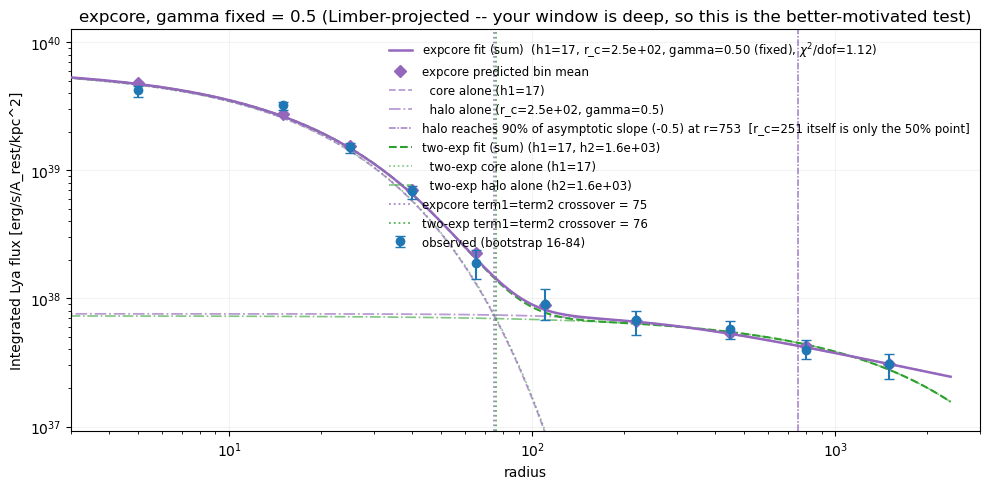

[psf expcore fit vs real data] converged  chi2/dof = 6.72/6 = 1.12
       A1 =    6.274e+39 +/- 5.12e+38  
       h1 =         16.8 +/- 1.12      
       A2 =    7.589e+37 +/- 2.26e+37  
      r_c =          251 +/- 192       
    gamma =          0.5 +/- 0          (fixed)


In [34]:
# ── exp-core + cored-power-law fit, gamma floating ──
# fig, ax, fit_free = fitting.plot_expcore_fit(
#     boot, method="psf", psf_fwhm=3.0, psf_beta=3.0, logx=True,
#     compare_result=fit_twoexp,     # overlays the two-exp curve + prints AIC/BIC
#     rvir_kpc=75,     # your fiducial Rvir -- checks r_c against it visually
# )

# ── test the literature-motivated FIXED slopes ──
# fig, ax, fit_g18 = fitting.plot_expcore_fit(
#     boot, method="psf", gamma_fixed=gamma_3d, compare_result=fit_twoexp, xlims=xlims, logx=True,
#     title=f"expcore, gamma fixed = {gamma_3d} (Limber-projected -- your window is deep, so this is the better-motivated test)",
# )

# fig, ax, fit_g08 = fitting.plot_expcore_fit(
#     boot, method="psf", gamma_fixed=gamma_2d, compare_result=fit_twoexp, xlims=xlims, logx=True,
#     title=f"expcore, gamma fixed = {gamma_2d} (Limber-projected -- your window is deep, so this is the better-motivated test)",
# )

fig, ax, fit_g05 = fitting.plot_expcore_fit(
    boot, method="psf", gamma_fixed=chen2020, compare_result=fit_twoexp, xlims=xlims, logx=True,
    title=f"expcore, gamma fixed = {chen2020} (Limber-projected -- your window is deep, so this is the better-motivated test)",
)

In [32]:
# ── Cell: side-by-side comparison table ──
for label, res in [("two-exp", fit_twoexp), ("expcore free", fit_free),
                    (f"expcore gamma={gamma_3d}", fit_g18),
                    (f"expcore gamma={gamma_2d}", fit_g08),
                    (f"expcore gamma={chen2020}", fit_g05)]:
    if res.get("success"):
        gtxt = f"  gamma={res['gamma']:.2f}" if "gamma" in res else ""
        print(f"{label:24s} chi2/dof={res['chi2']/max(res['dof'],1):5.2f}{gtxt}")

fitting.compare_models_aic_bic(fit_twoexp, fit_g18, label_a="two-exp", label_b="expcore(1.8)")
fitting.compare_models_aic_bic(fit_twoexp, fit_g08, label_a="two-exp", label_b="expcore(0.8)")
fitting.compare_models_aic_bic(fit_g08, fit_g05, label_a="expcore(0.8)", label_b="expcore(0.5)")

two-exp                  chi2/dof= 1.17
expcore free             chi2/dof= 1.32  gamma=0.64
expcore gamma=1.8        chi2/dof= 1.24  gamma=1.80
expcore gamma=0.8        chi2/dof= 1.11  gamma=0.80
expcore gamma=0.6        chi2/dof= 1.10  gamma=0.60
compare_models_aic_bic: two-exp vs expcore(1.8)
     two-exp: chi2/dof=7.04/6  k=4  AIC=15.04  BIC=16.25
  expcore(1.8): chi2/dof=7.46/6  k=4  AIC=15.46  BIC=16.67
  delta AIC (expcore(1.8)-two-exp) = +0.41   delta BIC = +0.41
  preferred: AIC -> two-exp   BIC -> two-exp
compare_models_aic_bic: two-exp vs expcore(0.8)
     two-exp: chi2/dof=7.04/6  k=4  AIC=15.04  BIC=16.25
  expcore(0.8): chi2/dof=6.68/6  k=4  AIC=14.68  BIC=15.89
  delta AIC (expcore(0.8)-two-exp) = -0.36   delta BIC = -0.36
  preferred: AIC -> expcore(0.8)   BIC -> expcore(0.8)
compare_models_aic_bic: expcore(0.8) vs expcore(0.5)
  expcore(0.8): chi2/dof=6.68/6  k=4  AIC=14.68  BIC=15.89
  expcore(0.5): chi2/dof=6.61/6  k=4  AIC=14.61  BIC=15.82
  delta AIC (expcore(0.5)-e

{'expcore(0.8)': {'chi2': 6.681575403720412,
  'dof': 6,
  'k': 4,
  'AIC': 14.681575403720412,
  'BIC': 15.891915775696596},
 'expcore(0.5)': {'chi2': 6.613127262506359,
  'dof': 6,
  'k': 4,
  'AIC': 14.61312726250636,
  'BIC': 15.823467634482544},
 'delta_AIC (b-a)': -0.06844814121405207,
 'delta_BIC (b-a)': -0.06844814121405207,
 'preferred_by_AIC': 'expcore(0.5)',
 'preferred_by_BIC': 'expcore(0.5)'}

In [15]:
# ── Cell: reproduce the window-depth check above for your actual fiducial z ──
from astropy.cosmology import Planck18
c, lya_rest = 299792.458, 1215.67
dv_half = c * 3.0 / lya_rest                       # +/-3A rest-frame -> km/s
z = 2.3                                            # <- set to your sample's real z
dchi_half = (1 + z) * dv_half / Planck18.H(z).value
print(f"dv_half={dv_half:.0f} km/s -> comoving full window={2*dchi_half:.1f} Mpc "
      f"({2*dchi_half*Planck18.h:.1f} Mpc/h) at z={z}")

dv_half=740 km/s -> comoving full window=20.9 Mpc (14.2 Mpc/h) at z=2.3


In [16]:
# ── Optional: lower-level calls, no plotting wrapper ──
r_edges = boot["r_edges"]
r_mid = 0.5 * (r_edges[:-1] + r_edges[1:])
r_fine = fitting.default_fine_grid(r_edges)
psf_r = np.linspace(0, 60, 400)
psf_vals = fitting.moffat_1d(psf_r, fwhm=3.0, beta=3.0)
R = fitting.ring_convolution_matrix(r_fine, r_edges, psf_r, psf_vals)

y = np.asarray(boot["total_flux_fid"])
sigma = (np.asarray(boot["total_flux_hi"]) - np.asarray(boot["total_flux_lo"])) / 2.0

result = fitting.fit_psf_aware_expcore(r_mid, y, sigma, R, r_fine, r_edges,
                                        gamma_fixed=gamma_2d, verbose=True)
fitting.describe_fit_expcore(result, label="psf-expcore gamma=0.8")

r_plot = np.linspace(0.1, r_edges[-1], 300)
curve = fitting.intrinsic_profile_expcore(r_plot, result["A1"], result["h1"],
                                          result["A2"], result["r_c"], result["gamma"])

fit_psf_aware_expcore: WITH PSF forward model, all 10 bins fit (inner bin kept), gamma fixed=0.8
[psf-expcore] converged  chi2/dof = 6.68/6 = 1.11
       A1 =    6.261e+39 +/- 5.06e+38  
       h1 =        16.89 +/- 1.07      
       A2 =    7.113e+37 +/- 1.45e+37  
      r_c =          488 +/- 211       
    gamma =          0.8 +/- 0          (fixed)
    -> if gamma=0.80 is read as a 3D clustering slope, fully-projected (Limber) 2D slope = -0.20
[psf-expcore gamma=0.8] converged  chi2/dof = 6.68/6 = 1.11
       A1 =    6.261e+39 +/- 5.06e+38  
       h1 =        16.89 +/- 1.07      
       A2 =    7.113e+37 +/- 1.45e+37  
      r_c =          488 +/- 211       
    gamma =          0.8 +/- 0          (fixed)
    -> if gamma=0.80 is read as a 3D clustering slope, fully-projected (Limber) 2D slope = -0.20


# Injection Recovery

In [ ]:
# sanity check the ring-convolution math once
pfit.validate_ring_convolution()

In [ ]:
# CELL 1
REAL_FLUX_MED = np.array([
    4.16327760e+39, 3.21339899e+39, 1.51426526e+39, 6.75309539e+38,
    1.90587512e+38, 9.33952200e+37, 6.60216138e+37, 5.67617906e+37,
    4.03988530e+37, 3.03338227e+37,])
r_edges = pfit.EXAMPLE_R_EDGES_KPC
r_mid   = 0.5 * (r_edges[:-1] + r_edges[1:])
r_fine  = pfit.default_fine_grid(r_edges)
psf_r   = np.linspace(0, 60, 400)
psf_vals = pfit.moffat_1d(psf_r, fwhm=3.0, beta=3.0)
R = pfit.ring_convolution_matrix(r_fine, r_edges, psf_r, psf_vals, verbose=True)

In [ ]:
# CELL 2
seed = pfit.estimate_truth_from_profile(r_mid, REAL_FLUX_MED, verbose=True)
rough_sigma = 0.3 * np.abs(REAL_FLUX_MED)
calib = pfit.fit_naive(r_mid, r_edges, r_fine, REAL_FLUX_MED, rough_sigma,
                       fit_skip_inner=0, p0=seed, verbose=True)
truth = (calib["A1"], calib["h1"], calib["A2"], calib["h2"]) if calib["success"] else seed

In [ ]:
# CELL 3  -- pass r_edges + R so the overlay is in the same units as the data
fig, ax = pfit.plot_recovery_case(r_fine, truth, r_mid, REAL_FLUX_MED, rough_sigma,
                                  calib, {"success": False}, r_edges=r_edges, R=R,
                                  title="calibration check")
plt.plot(r_mid, REAL_FLUX_MED)
plt.xlim(0.5, 5000)
plt.xscale("log")

In [ ]:
# CELL 4
sigma, R = pfit.sigma_from_target_sn(truth, r_edges, r_fine, psf_r, psf_vals,
                                     pfit.EXAMPLE_FLUX_SN, R=R, verbose=True)
obs = pfit.make_fake_observation(truth, r_edges, r_fine, psf_r, psf_vals,
                                 noise_sigma_per_bin=sigma, R=R, seed=0, verbose=True)
y = obs["total_flux_fid"]
naive   = pfit.fit_naive(r_mid, r_edges, r_fine, y, sigma, verbose=True)
psf_fit = pfit.fit_psf_aware(r_mid, y, sigma, R, r_fine, r_edges, verbose=True)

In [ ]:
fig, ax = pfit.plot_recovery_case(r_fine, truth, r_mid, y, sigma, naive, psf_fit,
                                  r_edges=r_edges, R=R, title="synthetic recovery")

fig, ax = pfit.plot_recovery_case(r_fine, truth, r_mid, y, sigma, naive, psf_fit,
                                  r_edges=r_edges, R=R, title="synthetic recovery")
plt.xlim(0.5, 5000)
plt.xscale("log")

In [ ]:
# CELL 5
mc = pfit.monte_carlo_recovery(truth, r_edges, r_fine, psf_r, psf_vals,
                               noise_sigma_per_bin=sigma, n_draws=500, seed=1, verbose=True)
pfit.plot_recovery_histograms(mc, param="h1")
pfit.plot_recovery_histograms(mc, param="h2")

# ---------------------------------------
# UV Extraction Fit
# ---------------------------------------

In [50]:
uvcfg = uv.UVExtractConfig(
    bins_kpc=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14],
    psf_seeing_header_keys=("IQIMAGE", "FINALIQ"),
    psf_fwhm_arcsec={},
    psf_beta=3.0,
    flux_combine_method="biweight",
    mask_annulus_neighbors=True,
    psf_sat_level=5000,
    psf_sat_frac=1.0,
    psf_empirical={
        "AEGIS": {
            "r_arcsec": [0.1000, 0.3000, 0.5000, 0.7000, 0.9000, 1.1000, 1.3000, 1.5000, 1.7000, 1.9000, 2.1000, 2.3000, 2.5000, 2.7000, 2.9000, 3.1000, 3.3000, 3.5000, 3.7000, 3.9000, 4.1000, 4.3000],
            "value":    [1.000000e+00, 6.781182e-01, 3.302014e-01, 1.499491e-01, 6.800903e-02, 3.298404e-02, 1.766485e-02, 1.037221e-02, 6.505302e-03, 4.295045e-03, 2.925033e-03, 2.063926e-03, 1.481029e-03, 1.104248e-03, 8.296371e-04, 6.267669e-04, 4.809497e-04, 3.677402e-04, 2.845379e-04, 2.317465e-04, 1.706528e-04, 1.277073e-04],
        },
        "COSMOS": {
            "r_arcsec": [0.1000, 0.3000, 0.5000, 0.7000, 0.9000, 1.1000, 1.3000, 1.5000, 1.7000, 1.9000, 2.1000, 2.3000, 2.5000, 2.7000, 2.9000, 3.1000, 3.3000, 3.5000, 3.7000, 3.9000, 4.1000, 4.3000],
            "value":    [1.000000e+00, 6.588179e-01, 3.051158e-01, 1.333684e-01, 5.843185e-02, 2.801081e-02, 1.488085e-02, 8.623744e-03, 5.382233e-03, 3.517150e-03, 2.386557e-03, 1.658766e-03, 1.181375e-03, 8.570970e-04, 6.356186e-04, 4.725871e-04, 3.625894e-04, 2.747803e-04, 2.073191e-04, 1.554781e-04, 1.234245e-04, 9.341825e-05],
        },
    },
)

print(uvcfg)

UVExtractConfig(image_paths={'AEGIS': 'catalogs/images/groth.fits', 'COSMOS': 'catalogs/images/cosmos.fits'}, bg_segmap_paths={'AEGIS': 'catalogs/images/fibermask_EGS.fits', 'COSMOS': 'catalogs/images/fibermask_COSMOS.fits'}, cutout_margin_factor=1.5, centroid_window_arcsec=3.0, centroid_offset_flag_arcsec=0.5, bg_method='masked_median', bins_kpc=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14], field_cutout_margin_factor=2.0, flux_combine_method='biweight', mask_annulus_neighbors=True, psf_fwhm_arcsec={}, psf_seeing_header_keys=('IQIMAGE', 'FINALIQ'), psf_beta=3.0, psf_moffat_params={}, psf_empirical={'AEGIS': {'r_arcsec': [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5, 2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3], 'value': [1.0, 0.6781182, 0.3302014, 0.1499491, 0.06800903, 0.03298404, 0.01766485, 0.01037221, 0.006505302, 0.004295045, 0.002925033, 0.002063926, 0.001481029, 0.001104248, 0.0008296371, 0.0006267669, 0.0004809497, 0.0003677402, 0.0002845379, 0.0002317465, 0.00

In [51]:
catalog = uv.get_uv_sample_catalog(cfg2)
catalog[:5]   # quick peek

Loaded BOTH: 244 AEGIS + 278 COSMOS = 522
Finite-spectrum cut (bin 9, > 100 px): kept 510 / 522 galaxies
get_uv_sample_catalog: 510 galaxies (same sample as the Lya spectral stack for this config).


INDEX,FIELD,CATALOG,ID,ID_V21,ID_V41,MASKNAME,SLITOBJNAME,RA,DEC,z,Z_QUAL,HA_FLUX,HA_FLUX_ERR,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_FWHM,HB_FWHM_ERR,HG_FLUX,HG_FLUX_ERR,HG_FWHM,HG_FWHM_ERR,HD_FLUX,HD_FLUX_ERR,HD_FWHM,HD_FWHM_ERR,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_FWHM,OII3730_FWHM_ERR,OIII4364_FLUX,OIII4364_FLUX_ERR,OIII4364_FWHM,OIII4364_FWHM_ERR,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_FWHM,OIII5008_FWHM_ERR,OI6302_FLUX,OI6302_FLUX_ERR,OI6302_FWHM,OI6302_FWHM_ERR,NII6550_FLUX,NII6550_FLUX_ERR,NII6550_FWHM,NII6550_FWHM_ERR,NII6585_FLUX,NII6585_FLUX_ERR,NII6585_FWHM,NII6585_FWHM_ERR,SII6718_FLUX,SII6718_FLUX_ERR,SII6718_FWHM,SII6718_FWHM_ERR,SII6733_FLUX,SII6733_FLUX_ERR,SII6733_FWHM,SII6733_FWHM_ERR,NEIII3870_FLUX,NEIII3870_FLUX_ERR,NEIII3870_FWHM,NEIII3870_FWHM_ERR,NEIII3969_FLUX,NEIII3969_FLUX_ERR,NEIII3969_FWHM,NEIII3969_FWHM_ERR,NIIHA,NIIHA_ERR,MASS_50,MASS_16,MASS_84,SFR_50,SFR_16,SFR_84,SSFR_50,SSFR_16,SSFR_84,AV_50,AV_16,AV_84,AGE_50,AGE_16,AGE_84,TAU_50,TAU_16,TAU_84,CHI2,ZFAST,EBV_STAR_16,EBV_STAR_50,EBV_STAR_84,HA_SN,HA_FLAG,HB_SN,HB_FLAG,HG_SN,HG_FLAG,HD_SN,HD_FLAG,OII3727_SN,OII3727_FLAG,OII3730_SN,OII3730_FLAG,OIII4364_SN,OIII4364_FLAG,OIII4960_SN,OIII4960_FLAG,OIII5008_SN,OIII5008_FLAG,OI6302_SN,OI6302_FLAG,NII6550_SN,NII6550_FLAG,NII6585_SN,NII6585_FLAG,SII6718_SN,SII6718_FLAG,SII6733_SN,SII6733_FLAG,NEIII3870_SN,NEIII3870_FLAG,NEIII3969_SN,NEIII3969_FLAG,O3,O3_ERR,O32,O32_ERR,EBV_NEB_16,EBV_NEB_50,EBV_NEB_84,FLUX_RADIUS,A_IMAGE,B_IMAGE,THETA_J2000,KRON_RADIUS,FWHM_IMAGE,CLASS_STAR,F_F160W,E_F160W,F_F814W,E_F814W,F_F606W,E_F606W,F_G,E_G,F_R,E_R,F_V,E_V,F_IRAC1,E_IRAC1,IRAC1_CONTAM,F_IRAC2,E_IRAC2,IRAC2_CONTAM,F_IRAC3,E_IRAC3,IRAC3_CONTAM,F_IRAC4,E_IRAC4,IRAC4_CONTAM,USE_PHOT,STAR_FLAG,PHOT_FLAGS,Z_SPEC,TOT_COR,SKELTON_MATCH,BA,INCL_DEG,GALFIT_FLAG_F160W,GALFIT_MAG_F160W,GALFIT_MAG_ERR_F160W,RE_F160W,RE_ERR_F160W,N_F160W,N_ERR_F160W,Q_F160W,Q_ERR_F160W,PA_F160W,PA_ERR_F160W,SN_F160W,VDW_MATCH_F160W,GALFIT_FLAG_F125W,GALFIT_MAG_F125W,GALFIT_MAG_ERR_F125W,RE_F125W,RE_ERR_F125W,N_F125W,N_ERR_F125W,Q_F125W,Q_ERR_F125W,PA_F125W,PA_ERR_F125W,SN_F125W,VDW_MATCH_F125W,RE_BEST,RE_BEST_SRC,Q_BEST,Q_BEST_SRC,RE_CIRC_BEST,MAG_G,MAG_R,MAG_V,MAG_F606W,MAG_F814W,MAG_F160W,GR_COLOR,Z_SECURE,Z_INWINDOW,BEST_LINE_SN,LINE_SN_OK,COORDS_OK,SAMPLE,HAS_DUP_0p5AS,DUP_DROP,BLEND_DROP,BLEND_MERGE,KEEP,XRAY_MATCH,XRAY_SEP_AS,XRAY_NAME,XRAY_FLUX_B,XRAY_SIG,AGN_XRAY,NIIHA_OK,BPT_O3HB,BPT_N2HA,AGN_OPT_USABLE,AGN_OPT,DONLEY_X,DONLEY_Y,AGN_IR_USABLE,AGN_IR,AGN_FLAG,CLEAN,MEX_O3HB,AGN_MEX,MEX_INTERMED,AGN_MEX_USABLE,AGN_MEX_APPLIED,VALID,EBV
int64,str6,str6,int64,int64,int64,str8,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [52]:
# aegis_cutout_path = uv.build_field_cutout(
#     full_image_path=uvcfg.image_paths["AEGIS"],
#     catalog=catalog, field="AEGIS",
#     out_path="catalogs/images/groth_cutout.fits",
#     z_col=cfg2.z_col, bins_kpc=uvcfg.bins_kpc,
#     margin_factor=uvcfg.field_cutout_margin_factor,
#     overwrite=True,
# )

# cosmos_cutout_path = uv.build_field_cutout(
#     full_image_path=uvcfg.image_paths["COSMOS"],
#     catalog=catalog, field="COSMOS",
#     out_path="catalogs/images/cosmos_cutout.fits",
#     z_col=cfg2.z_col, bins_kpc=uvcfg.bins_kpc,
#     margin_factor=uvcfg.field_cutout_margin_factor,
#     overwrite=True,
# )

cosmos_cutout_path = 'catalogs/images/cosmos_cutout.fits'
aegis_cutout_path = 'catalogs/images/groth_cutout.fits'

In [53]:
uv.validate_cutout_covers_sample(
    aegis_cutout_path, catalog, "AEGIS",
    z_col=cfg2.z_col, bins_kpc=uvcfg.bins_kpc,
    margin_factor=uvcfg.field_cutout_margin_factor,
)
uv.validate_cutout_covers_sample(
    cosmos_cutout_path, catalog, "COSMOS",
    z_col=cfg2.z_col, bins_kpc=uvcfg.bins_kpc,
    margin_factor=uvcfg.field_cutout_margin_factor,
)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


validate_cutout_covers_sample [AEGIS]: 233/233 galaxies fully covered (margin=2.0x outermost bin); 0 too close to the cutout edge or outside it entirely.
validate_cutout_covers_sample [COSMOS]: 277/277 galaxies fully covered (margin=2.0x outermost bin); 0 too close to the cutout edge or outside it entirely.


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


True

## Running the Extraction (takes a few min)

In [54]:
results_aegis = uv.run_uv_extraction_testbed(cfg2, uvcfg, "AEGIS", cutout_image_path=aegis_cutout_path)
results_cosmos = uv.run_uv_extraction_testbed(cfg2, uvcfg, "COSMOS", cutout_image_path=cosmos_cutout_path)

Loaded BOTH: 244 AEGIS + 278 COSMOS = 522
Finite-spectrum cut (bin 9, > 100 px): kept 510 / 522 galaxies
get_uv_sample_catalog: 510 galaxies (same sample as the Lya spectral stack for this config).


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


align_segmap_to_grid: catalogs/images/fibermask_EGS.fits -> 92.6% of the target grid falls inside the segmap's footprint (the rest is treated as masked, not confirmed clean sky); 8462945/49179402 (17.2%) pixels masked overall.
compute_field_background (masked_median): 40716457 unmasked px, median=-0.07355, std=0.2065
extract_uv_profiles_for_field [AEGIS]: 233 galaxies, image=catalogs/images/groth_cutout.fits
read_seeing_fwhm_arcsec [AEGIS]: header FINALIQ=0.8300" (from catalogs/images/groth_cutout.fits).


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


UV extract AEGIS:   0%|          | 0/233 [00:00<?, ?it/s]

...

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


align_segmap_to_grid: catalogs/images/fibermask_COSMOS.fits -> 100.0% of the target grid falls inside the segmap's footprint (the rest is treated as masked, not confirmed clean sky); 2190727/18062527 (12.1%) pixels masked overall.
compute_field_background (masked_median): 15871800 unmasked px, median=-0.0928, std=0.2267
extract_uv_profiles_for_field [COSMOS]: 277 galaxies, image=catalogs/images/cosmos_cutout.fits
read_seeing_fwhm_arcsec [COSMOS]: header IQIMAGE=0.7510" (from catalogs/images/cosmos_cutout.fits).


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


UV extract COSMOS:   0%|          | 0/277 [00:00<?, ?it/s]

summarize_uv_extraction [COSMOS]: 277 galaxies, 52 flagged (18.8%, 0 of those from a failed centroid fit) -- KEPT, not dropped, per spec. Median/max offset = 0.095" / 9.319".
  neighbor masking: 561/3176 annulus-bins (17.7%) had >=1 pixel masked from the segmap (median excluded fraction where contaminated: 30.9%).


In [55]:
results_all = results_aegis + results_cosmos
print(f"{len(results_all)} galaxies total ({len(results_aegis)} AEGIS + {len(results_cosmos)} COSMOS)")

510 galaxies total (233 AEGIS + 277 COSMOS)


## Bootstrap and Stack

In [ ]:
coadd, boot = uv.stack_and_bootstrap_uv(results_all, uvcfg.bins_kpc,
                                         method="biweight", nboot=10000)

coadd_cosmos, boot_cosmos = uv.stack_and_bootstrap_uv(results_all, uvcfg.bins_kpc,
                                         method="biweight", nboot=5000)
coadd_aegis, boot_aegis = uv.stack_and_bootstrap_uv(results_all, uvcfg.bins_kpc,
                                         method="biweight", nboot=5000)

## PSF Building

In [57]:
psf_r, psf_vals = uv.build_effective_psf_uv(results_all, uvcfg)

build_effective_psf_uv: averaged 510 flux-normalized per-galaxy PSFs -- 510 empirical (fields ['AEGIS', 'COSMOS']), 0 Moffat (beta value(s) []); kpc FWHM min/median/max = 5.61/6.39/7.13; grid 0..142.6 kpc, 400 pts.


## Fitting

### Exponential Profile

fit_and_plot_uv_coadd: y-errors from bootstrap_uv_coadd's 10000-draw 16/84 band.
fit_naive_uv_exp: NO PSF, dropped 1 inner bin(s) (11 bins fit, 1 excluded)
[naive-uv-exp] converged  chi2/dof = 28.57/9 = 3.17
       A =        4.955 +/- 0.116     
    h_uv =        3.143 +/- 0.037     


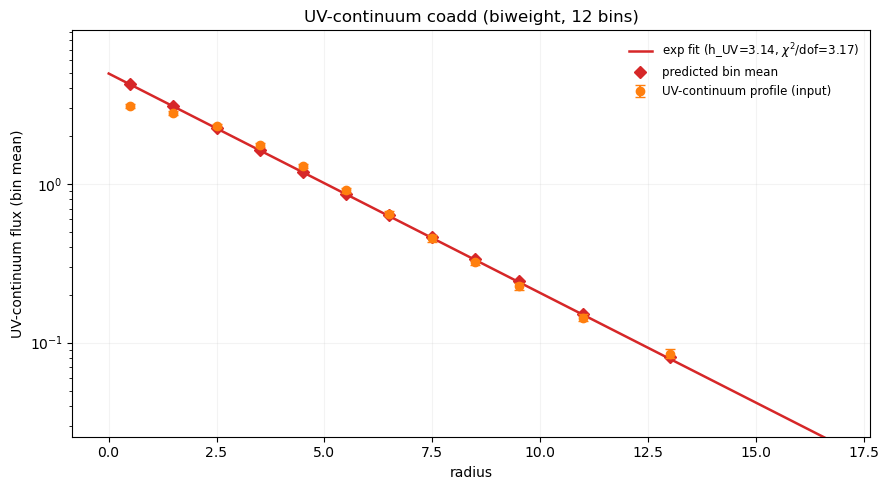

[naive UV exp fit] converged  chi2/dof = 28.57/9 = 3.17
       A =        4.955 +/- 0.116     
    h_uv =        3.143 +/- 0.037     
done


In [58]:
uv.fit_and_plot_uv_coadd(coadd, boot=boot,
    model="exp",
    fit_method="naive")

print('done')

fit_and_plot_uv_coadd: y-errors from bootstrap_uv_coadd's 10000-draw 16/84 band.
fit_psf_aware_uv_exp: WITH PSF forward model, all 12 bins fit (inner bin kept)
[psf-uv-exp] converged  chi2/dof = 42.41/10 = 4.24
       A =         20.5 +/- 0.93      
    h_uv =        1.551 +/- 0.0362    


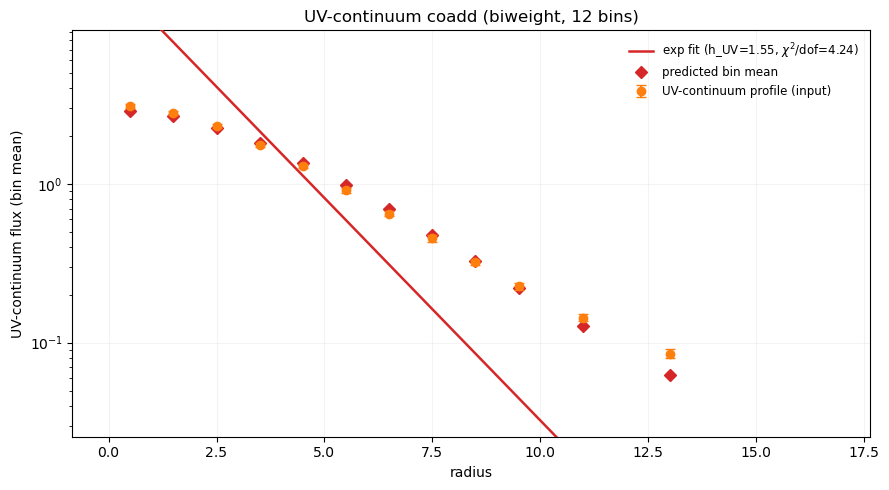

[psf UV exp fit] converged  chi2/dof = 42.41/10 = 4.24
       A =         20.5 +/- 0.93      
    h_uv =        1.551 +/- 0.0362    
done


In [60]:
uv.fit_and_plot_uv_coadd(coadd, boot=boot,
    model="exp",
    fit_method="psf",
    psf_r=psf_r,
    psf_vals=psf_vals)

print('done')

### Sersic Profile (with and without PSF)

fit_and_plot_uv_coadd: y-errors from bootstrap_uv_coadd's 10000-draw 16/84 band.
fit_naive_uv_sersic: NO PSF, dropped 1 inner bin(s) (11 bins fit, 1 excluded), n free
[naive-uv-sersic] converged  chi2/dof = 17.75/8 = 2.22
       A =       0.9877 +/- 0.0274    
     r_e =         5.19 +/- 0.0585    
       n =       0.8806 +/- 0.0336    


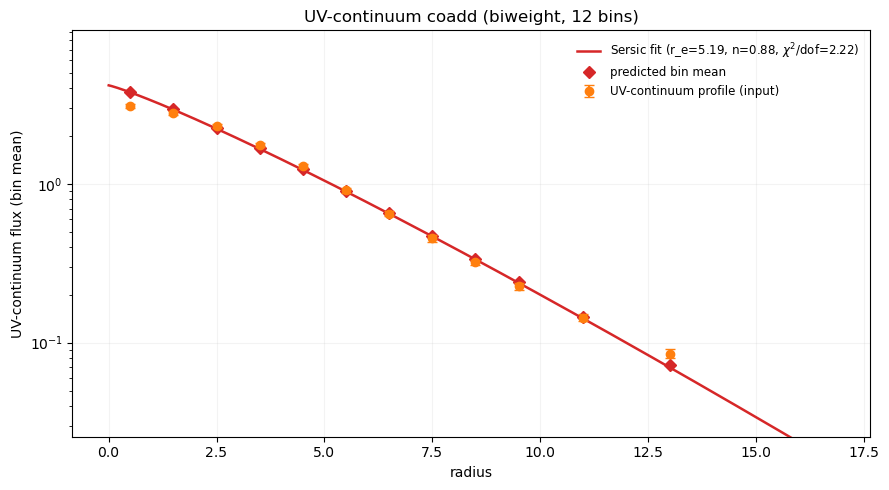

[naive UV sersic fit] converged  chi2/dof = 17.75/8 = 2.22
       A =       0.9877 +/- 0.0274    
     r_e =         5.19 +/- 0.0585    
       n =       0.8806 +/- 0.0336    
done


In [61]:
uv.fit_and_plot_uv_coadd(coadd, boot=boot,
    model="sersic",
    fit_method="naive")

print('done')

fit_and_plot_uv_coadd: y-errors from bootstrap_uv_coadd's 10000-draw 16/84 band.
fit_psf_aware_uv_sersic: WITH PSF forward model, all 12 bins fit (inner bin kept), n free
[psf-uv-sersic] converged  chi2/dof = 0.80/9 = 0.09
       A =        3.365 +/- 0.284     
     r_e =         2.25 +/- 0.0932    
       n =        2.851 +/- 0.544     


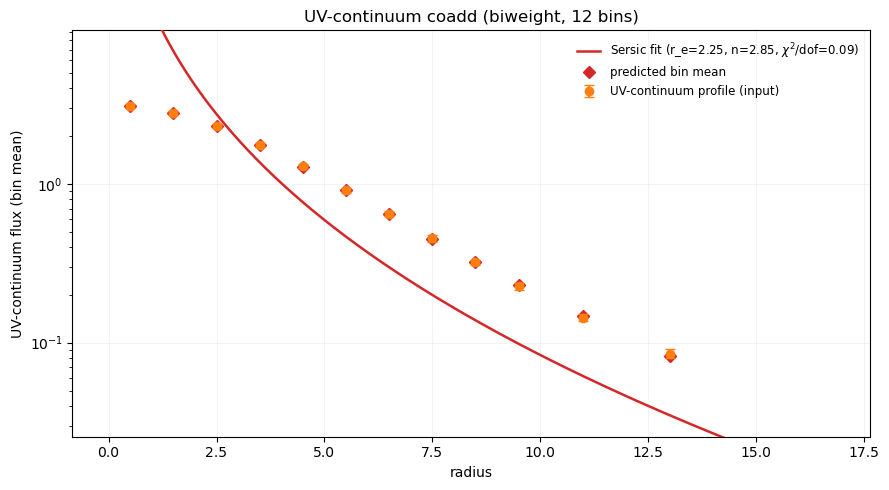

[psf UV sersic fit] converged  chi2/dof = 0.80/9 = 0.09
       A =        3.365 +/- 0.284     
     r_e =         2.25 +/- 0.0932    
       n =        2.851 +/- 0.544     
done


In [62]:
uv.fit_and_plot_uv_coadd(coadd, boot=boot,
    model="sersic",
    fit_method="psf",
    psf_r=psf_r,
    psf_vals=psf_vals)

print('done')

# Measuring PSF via Stars

In [27]:
# ---- knobs ----
field_select = 'COSMOS'                       # 'AEGIS' or 'COSMOS'
image_path = uv.resolve_uv_image_path(field_select, uvcfg)   # or a cutout path you built
combine_method = "biweight"                    # per-pixel SB; 'biweight' also fine

In [28]:
# ---- obtain field stars ----
star_mag_min, star_mag_max = 17, 23

if (field_select == 'AEGIS'):
    ra_min, ra_max = 214.6, 215.2
    dec_min, dec_max = 52.7, 53.0
elif (field_select == 'COSMOS'):
    ra_min, ra_max = 149.9, 150.3
    dec_min, dec_max = 2.1, 2.5
else:
    print('Did not set bounds, specify field using either COSMOS or AEGIS')

query = f"""
SELECT
    ra, dec, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {ra_min} AND {ra_max}
AND dec BETWEEN {dec_min} AND {dec_max}
AND parallax_over_error > 5
AND phot_g_mean_mag BETWEEN {star_mag_min} AND {star_mag_max}
"""

job = Gaia.launch_job(query)
stars = job.get_results()

print(len(stars))
stars[:5]

70


ra,dec,phot_g_mean_mag
deg,deg,mag
float64,float64,float32
149.96304552151068,2.238139093927207,17.295382
150.18402321757176,2.1633803085024708,17.078835
150.08573568714667,2.146685964788726,17.681656
150.24770428295028,2.463207880755581,17.226442
149.91059941340163,2.1348116907946326,18.404392


In [29]:
# measure the stellar PSF — stamp-independent (core saturation + fixed sky-annulus background)
r_mid, stack_stars, profiles, qc = uv.measure_stellar_psf(
    stars, image_path, uvcfg, field_select,
    r_edges_arcsec=np.arange(0.0, 4.501, 0.20),   # ~1.1-pixel bins (no sub-pixel core)
)
star_scatter = np.nanstd(profiles, axis=0)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


measure_stellar_psf [COSMOS]: kept 57 stars (rejected 8 saturated-core, 0 off-image/low-coverage, 0 bad centroid, 5 shape-outlier). biweight stack, bootstrap err (n_boot=2000). sat_core=1.13" (>= 5000 cts rejects), core_norm=0.38", sky=[4.40,6.60]", stamp=17.2" (internal).


In [30]:
qc

{'kept': 57,
 'saturated': 8,
 'off_image': 0,
 'bad_centroid': 0,
 'shape_clipped': 5,
 'seeing_hdr_arcsec': 0.751,
 'sat_core_arcsec': 1.1265,
 'sat_level': 5000.0,
 'sat_frac': 1.0,
 'core_norm_arcsec': 0.3755,
 'sky_annulus_arcsec': (4.4, 6.6000000000000005),
 'stamp_arcsec': 17.160000000000004,
 'stack_err': array([3.05934442e-03, 1.01978147e-03, 3.05514911e-03, 1.32174916e-03,
        7.14859526e-04, 2.53383913e-04, 9.60800860e-05, 5.38996329e-05,
        3.98615261e-05, 2.90820492e-05, 2.08328408e-05, 1.26280598e-05,
        9.49686678e-06, 8.40710629e-06, 8.37389650e-06, 7.65525253e-06,
        7.82298280e-06, 5.51276088e-06, 4.54704713e-06, 4.06252901e-06,
        5.55272949e-06, 4.58339854e-06])}

fit_moffat_psf: FWHM = 0.6554 +/- 0.0124"   beta = 2.245 +/- 0.038   (log fit over 22 bins, best of 17/17 seeds)


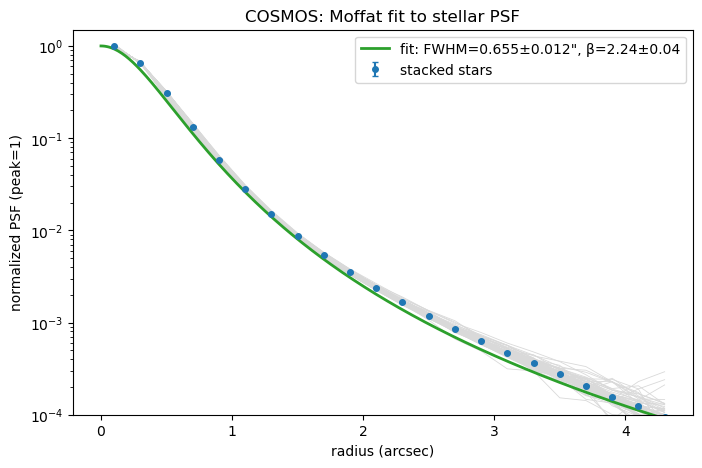

In [31]:
# fit Moffat — FWHM + β free, now multi-seed
fitres = uv.fit_moffat_psf(r_mid, stack_stars, sigma=qc['stack_err'])
uvcfg.psf_moffat_params[field_select] = {"fwhm_arcsec": fitres["fwhm"], "beta": fitres["beta"]}

# overlay
rr = np.linspace(0, r_mid.max(), 300)
mm = uv.moffat_1d(rr, fwhm=fitres["fwhm"], beta=fitres["beta"]);
mm /= mm.max()

fig, ax = plt.subplots(figsize=(8, 5))
for p in profiles: ax.plot(r_mid, p/stack_stars[0], color="0.85", lw=0.6)
ax.errorbar(r_mid, stack_stars/stack_stars[0], yerr=qc['stack_err'], fmt="o", color="tab:blue",
        ms=4, capsize=2, label="stacked stars")
ax.plot(rr, mm, "-", color="tab:green", lw=2,
        label=f"fit: FWHM={fitres['fwhm']:.3f}±{fitres['fwhm_err']:.3f}\", β={fitres['beta']:.2f}±{fitres['beta_err']:.2f}")
ax.set_yscale("log"); ax.set_ylim(1e-4, 1.5)
ax.set_xlabel("radius (arcsec)"); ax.set_ylabel("normalized PSF (peak=1)")
ax.set_title(f"{field_select}: Moffat fit to stellar PSF"); ax.legend(); plt.show()

In [32]:
print(uv.psf_empirical_entry("COSMOS", r_mid, stack_stars/stack_stars[0]))

# COSMOS: 22 bins -- paste into uvcfg.psf_empirical
psf_empirical["COSMOS"] = {
    "r_arcsec": [0.1000, 0.3000, 0.5000, 0.7000, 0.9000, 1.1000, 1.3000, 1.5000, 1.7000, 1.9000, 2.1000, 2.3000, 2.5000, 2.7000, 2.9000, 3.1000, 3.3000, 3.5000, 3.7000, 3.9000, 4.1000, 4.3000],
    "value":    [1.000000e+00, 6.588179e-01, 3.051158e-01, 1.333684e-01, 5.843185e-02, 2.801081e-02, 1.488085e-02, 8.623744e-03, 5.382233e-03, 3.517150e-03, 2.386557e-03, 1.658766e-03, 1.181375e-03, 8.570970e-04, 6.356186e-04, 4.725871e-04, 3.625894e-04, 2.747803e-04, 2.073191e-04, 1.554781e-04, 1.234245e-04, 9.341825e-05],
}
{'r_arcsec': [0.1, 0.30000000000000004, 0.5, 0.7000000000000001, 0.9, 1.1, 1.3000000000000003, 1.5, 1.7000000000000002, 1.9, 2.1, 2.3000000000000003, 2.5, 2.7, 2.9000000000000004, 3.1, 3.3000000000000003, 3.5, 3.7, 3.9000000000000004, 4.1, 4.300000000000001], 'value': [1.0, 0.6588178541628086, 0.30511584099445904, 0.13336843221512218, 0.05843185303803145, 0.02801080918261419, 0.01488084521388796

In [26]:
print(uv.psf_empirical_entry("AEGIS", r_mid, stack_stars/stack_stars[0]))

# AEGIS: 22 bins -- paste into uvcfg.psf_empirical
psf_empirical["AEGIS"] = {
    "r_arcsec": [0.1000, 0.3000, 0.5000, 0.7000, 0.9000, 1.1000, 1.3000, 1.5000, 1.7000, 1.9000, 2.1000, 2.3000, 2.5000, 2.7000, 2.9000, 3.1000, 3.3000, 3.5000, 3.7000, 3.9000, 4.1000, 4.3000],
    "value":    [1.000000e+00, 6.781182e-01, 3.302014e-01, 1.499491e-01, 6.800903e-02, 3.298404e-02, 1.766485e-02, 1.037221e-02, 6.505302e-03, 4.295045e-03, 2.925033e-03, 2.063926e-03, 1.481029e-03, 1.104248e-03, 8.296371e-04, 6.267669e-04, 4.809497e-04, 3.677402e-04, 2.845379e-04, 2.317465e-04, 1.706528e-04, 1.277073e-04],
}
{'r_arcsec': [0.1, 0.30000000000000004, 0.5, 0.7000000000000001, 0.9, 1.1, 1.3000000000000003, 1.5, 1.7000000000000002, 1.9, 2.1, 2.3000000000000003, 2.5, 2.7, 2.9000000000000004, 3.1, 3.3000000000000003, 3.5, 3.7, 3.9000000000000004, 4.1, 4.300000000000001], 'value': [1.0, 0.6781182111040189, 0.33020144441477894, 0.14994914887724378, 0.06800903106993227, 0.03298404401596906, 0.017664848705465204,